# Copilot

In [168]:
from datetime import datetime

from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Correct data

In [169]:
df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
# df1 = pd.read_csv(f'data/autoscout/24.05.14_autoscout_raw.csv')
df1['description'] = df1['title'] + ' ' + df1['description']
df1['location'] = df1['location'].str.extract(r'ES-\d+\s(.*)', expand=False)
df1['year'] = df1['year'].str.split('/').str[1].astype(int)
df1 = df1.drop(['title', 'rating', 'transmission'], axis=1)
df1['location'] = df1['location'].str.capitalize()
df1['brand'] = df1['brand'].str.capitalize()
df1

,brand,description,full_price,mileage,year,fuel,cv,location,url
0,Dacia,Dacia Dokker 1.6 Essential GLP 75kW,8388,61000,2019,Gas licuado (GLP),102,Torrejón de ardoz,https://www.autoscout24.es//anuncios/dacia-dok...
1,Dacia,Dacia Dokker 1.6 Essential GLP 75kW,8388,61000,2019,Gas licuado (GLP),102,Guadalajara,https://www.autoscout24.es//anuncios/dacia-dok...
2,Ford,Ford Focus Sb. 1.0 Ecoboost Auto-S&S Trend+ 125,8800,86495,2017,Gasolina,125,Parla,https://www.autoscout24.es//anuncios/ford-focu...
3,Dacia,Dacia Dokker 1.6 Essential 75kW,8890,72900,2019,Gasolina,102,Humanes de madrid.,https://www.autoscout24.es//anuncios/dacia-dok...
4,Dacia,Dacia Logan MCV 0.9 TCE Laureate,8990,76058,2018,Gasolina,90,Las rozas,https://www.autoscout24.es//anuncios/dacia-log...
...,...,...,...,...,...,...,...,...,...
5060,Infiniti,Infiniti QX30 2.2d Premium AWD 7DCT,20000,68626,2019,Diésel,170,Madrid,https://www.autoscout24.es//anuncios/infiniti-...
5061,Infiniti,Infiniti QX30 2.2d Premium AWD 7DCT,20000,68626,2019,Diésel,170,Leganes,https://www.autoscout24.es//anuncios/infiniti-...
5062,Infiniti,Infiniti QX30 2.2d Premium AWD 7DCT,20000,68626,2019,Diésel,170,Leganés,https://www.autoscout24.es//anuncios/infiniti-...
5063,Seat,SEAT Ateca 1.4 EcoTSI S&S FR,20000,73931,2017,Gasolina,150,Madrid,https://www.autoscout24.es//anuncios/seat-atec...


In [170]:
df2 = pd.read_csv(f'data/flexicar/{datetime.now().strftime("%y.%m.%d")}_flexicar_raw.csv')
# df2 = pd.read_csv(f'data/flexicar/24.05.14_flexicar_raw.csv')
df2['cv'] = df2['description'].str.extract(r'\((\d+)CV\)', expand=False)
mask = pd.isna(df2['cv'])
df2['location'] = df2['city']
df2['location'] = df2['location'].str.capitalize()
df2.loc[mask, 'cv'] = df2.loc[mask, 'url'].str.extract(r'(\d+)(?:-cv|cv)(?!.*(?:-cv|cv))', expand=False)
df2['cv'] = df2['cv'].replace(np.nan, '0')
df2['cv'] = df2['cv'].astype(int)
df2['cv'] = df2['cv'].replace(0, np.nan)
df2['title'] = df2['title'].str.strip()
df2['description'] = df2['title'] + ' ' + df2['description']
df2['brand'] = df2['title'].str.split(' ').str[0]
df2['brand'] = df2['brand'].str.capitalize()
df2 = df2.drop(['title', 'discounted_price', 'monthly_rate', 'iva_deducible', 'offer', 'city', 'transmission'], axis=1)
df2

,full_price,description,year,mileage,fuel,url,cv,location,brand
0,10990.0,Renault Clio Sp. T. Limited En. TCe 66kW (90CV...,2018,78500,Gasolina,https://www.flexicar.es//coches-ocasion/renaul...,90.0,Coslada,Renault
1,11790.0,Peugeot 308 SW Allure 1.2 PureTech 96KW (130CV...,2017,96905,Gasolina,https://www.flexicar.es//coches-ocasion/peugeo...,130.0,Autosmadrid leganés,Peugeot
2,10990.0,Citroen C3 Aircross BlueHDi 73kW (100CV) S&S FEEL,2019,68270,Diésel,https://www.flexicar.es//coches-ocasion/citroe...,100.0,San jose de valderas,Citroen
3,12490.0,Citroen C3 Aircross PureTech 81kW (110CV) S&S ...,2017,64541,Gasolina,https://www.flexicar.es//coches-ocasion/citroe...,110.0,Alcalá de henares,Citroen
4,11490.0,Hyundai ix20 1.4 CRDi BlueDrive 25 Aniversario,2017,70243,Diésel,https://www.flexicar.es//coches-ocasion/hyunda...,NaN,Autosmadrid leganés,Hyundai
...,...,...,...,...,...,...,...,...,...
490,NaN,Kia XCeed 1.6 GDi PHEV 104kW (141CV) eDrive,2021,72771,Híbrido,https://www.flexicar.es//coches-ocasion/kia-xc...,141.0,Autosmadrid alcalá de henares,Kia
491,21990.0,Land Rover Range Rover Evoque 2.0L eD4 Diesel ...,2018,45848,Diésel,https://www.flexicar.es//coches-ocasion/land-r...,150.0,Autosmadrid alcorcon,Land
492,22490.0,Toyota Corolla 2.0 180H FEEL! E-CVT TOURING SPORT,2019,93916,Híbrido,https://www.flexicar.es//coches-ocasion/toyota...,NaN,Autosmadrid san sebastián de los reyes,Toyota
493,21990.0,Audi Q2 Advanced 30 TDI 85kW (116CV) S tronic,2020,90661,Diésel,https://www.flexicar.es//coches-ocasion/audi-q...,116.0,Autosmadrid leganés,Audi


In [171]:
df3 = pd.read_csv(f'data/ocasion/{datetime.now().strftime("%y.%m.%d")}_ocasion_raw.csv')
# df3 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df3 = df3.loc[df3['status'] == 'Available']
df2['location'] = df2['location'].str.capitalize()
df3['description'] = df3['title'] + ' ' + df3['description']
df3['brand'] = df3['title'].str.split(' ').str[0]
df3['brand'] = df3['brand'].str.capitalize()
df3 = df3.drop(['title', 'discounted_price', 'discount', 'status', 'district', 'libro', 'warranty', 'owner', 'vista', 'transmission'], axis=1)
df3

,full_price,description,year,mileage,fuel,cv,location,url,brand
1,11990,Opel Crossland 1.2 Crossland (83 CV),2021,66110,Gasolina,83,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Opel
5,13500,Citroën C4 Picasso BlueHDi 100 S&S Live (100 CV),2017,80642,Diésel,100,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Citroën
6,13300,Opel Crossland X 1.2 S&S Design Line 120 Anive...,2019,72044,Gasolina,110,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Opel
7,13900,Opel Crossland 1.2 Crossland (83 CV),2021,83399,Gasolina,83,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Opel
8,13450,Skoda Fabia Combi 1.0 TSI Ambition (95 CV),2020,82828,Gasolina,95,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Skoda
...,...,...,...,...,...,...,...,...,...
164,22500,Mercedes Clase B Mercedes-Benz B 180 (122 CV) ...,2017,55987,Gasolina,122,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Mercedes
165,25300,Subaru XV 1.6 Sport Plus Auto (114 CV),2022,58525,Gasolina,114,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Subaru
166,22900,Skoda Karoq 1.6 TDI Ambition (115 CV),2020,60533,Diésel,115,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Skoda
167,21900,Renault Captur Zen TCe Micro Híbrido (140 CV) ...,2022,25781,Híbrido,140,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Renault


In [172]:
df4 = pd.read_csv(f'data/autocasion/{datetime.now().strftime("%y.%m.%d")}_autocasion_raw.csv')
# df4 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df4['title'] = df4['title'].str.strip()
df4['description'] = df4['title']
df4['brand'] = df4['title'].str.split(' ').str[0]
df4['brand'] = df4['brand'].str.capitalize()
df4 = df4.drop(['title'], axis=1)
df4

,full_price,year,mileage,fuel,location,url,cv,description,brand
0,18250,2020,87200,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,100,PEUGEOT 2008 1.5BlueHDi S&S Allure 100,Peugeot
1,17490,2019,56274,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,120,FIAT 500X 1.0 Firefly S&S Sport,Fiat
2,13490,2021,33901,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,83,OPEL Crossland 1.2 61kW 82CV,Opel
3,14295,2019,40000,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,128,SSANGYONG Tivoli G16 Premium 4x2,Ssangyong
4,17795,2019,66000,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,121,MAZDA CX-3 2.0 Skyactiv-G Zenith 2WD 89kW,Mazda
...,...,...,...,...,...,...,...,...,...
4422,19990,2019,47000,Híbrido,Madrid,https://www.autocasion.com/coches-segunda-mano...,187,FORD Mondeo Sportbreak 2.0 HEV Titanium,Ford
4423,15690,2019,97369,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,130,PEUGEOT 308 SW 1.5BlueHDi S&S GT Line 130,Peugeot
4424,11390,2018,64408,Diésel,Ávila,https://www.autocasion.com/coches-segunda-mano...,95,FIAT Tipo 1.3 MULTIJET EASY 95 4P,Fiat
4425,17500,2021,91800,Diésel,Toledo,https://www.autocasion.com/coches-segunda-mano...,115,VOLKSWAGEN Golf Variant 2.0TDI Life 85kW,Volkswagen


In [187]:
df2 = df2[df1.columns]
df3 = df3[df1.columns]
df4 = df4[df1.columns]
df = pd.concat([df1,df2,df3,df4], ignore_index=True)
df['location'] = df['location'].str.lower().str.strip()
df = df.drop_duplicates()
df = df.dropna(subset=['full_price', 'cv'])
df['age'] = 2024 - df['year']
df = df.drop(['year'], axis=1)

average_mileage_df = df.groupby('age')['mileage'].mean().reset_index()
average_mileage_df.columns = ['age', 'average_mileage']

df = pd.merge(df, average_mileage_df, on='age', how='left')
df['delta_mileage'] = df['mileage'] - df['average_mileage']

# df = df[df['full_price'] <= 15000]
df.drop_duplicates(subset=['brand', 'description', 'full_price', 'mileage', 'fuel', 'cv', 'age'], inplace=True)
df = df.reindex(columns=['fuel', 'brand', 'description', 'location', 'url', 'full_price', 'mileage', 'cv', 'delta_mileage', 'age'])
df.to_csv(f'data/assembled/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [188]:
average_mileage_df = df.groupby('age')['mileage'].mean().reset_index()
average_mileage_df.columns = ['age', 'average_mileage']

df = pd.merge(df, average_mileage_df, on='age', how='left')
df['delta_mileage'] = df['mileage'] - df['average_mileage']
df

,fuel,brand,description,location,url,full_price,mileage,cv,age,delta_mileage,average_mileage
0,Gas licuado (GLP),Dacia,Dacia Dokker 1.6 Essential GLP 75kW,torrejón de ardoz,https://www.autoscout24.es//anuncios/dacia-dok...,8388.0,61000,102.0,5,-7178.064215,68178.064215
1,Gasolina,Ford,Ford Focus Sb. 1.0 Ecoboost Auto-S&S Trend+ 125,parla,https://www.autoscout24.es//anuncios/ford-focu...,8800.0,86495,125.0,7,13285.207037,73209.792963
2,Gasolina,Dacia,Dacia Dokker 1.6 Essential 75kW,humanes de madrid.,https://www.autoscout24.es//anuncios/dacia-dok...,8890.0,72900,102.0,5,4721.935785,68178.064215
3,Gasolina,Dacia,Dacia Logan MCV 0.9 TCE Laureate,las rozas,https://www.autoscout24.es//anuncios/dacia-log...,8990.0,76058,90.0,6,4693.076634,71364.923366
4,Gasolina,Skoda,Skoda Fabia Combi 1.2 TSI Like 66kW,llerona,https://www.autoscout24.es//anuncios/skoda-fab...,8999.0,99100,90.0,7,25890.207037,73209.792963
...,...,...,...,...,...,...,...,...,...,...,...
7623,Híbrido,Ford,FORD Mondeo Sportbreak 2.0 HEV Titanium,madrid,https://www.autocasion.com/coches-segunda-mano...,19990.0,47000,187.0,5,-21178.064215,68178.064215
7624,Diésel,Peugeot,PEUGEOT 308 SW 1.5BlueHDi S&S GT Line 130,madrid,https://www.autocasion.com/coches-segunda-mano...,15690.0,97369,130.0,5,29190.935785,68178.064215
7625,Diésel,Fiat,FIAT Tipo 1.3 MULTIJET EASY 95 4P,ávila,https://www.autocasion.com/coches-segunda-mano...,11390.0,64408,95.0,6,-6956.923366,71364.923366
7626,Diésel,Volkswagen,VOLKSWAGEN Golf Variant 2.0TDI Life 85kW,toledo,https://www.autocasion.com/coches-segunda-mano...,17500.0,91800,115.0,3,29251.662900,62548.337100


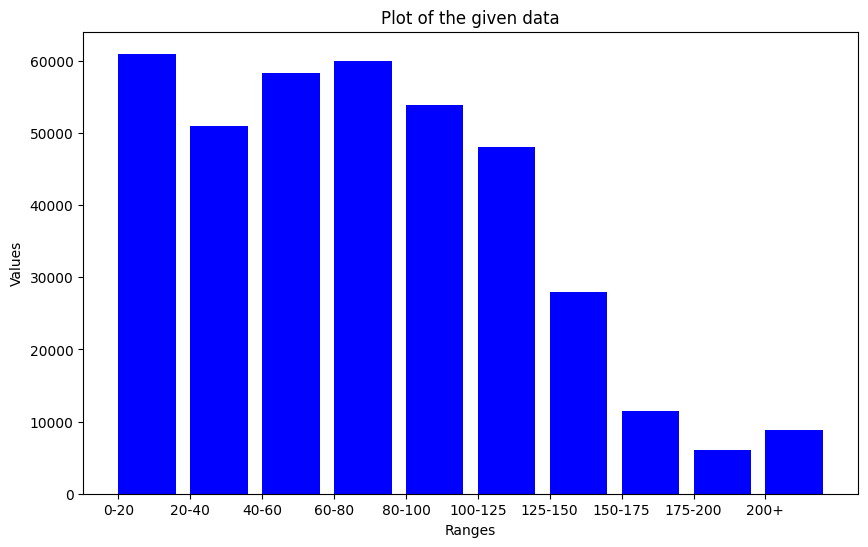

In [175]:
import matplotlib.pyplot as plt
import numpy as np

# Define the ranges and their corresponding values
ranges = ['0-20', '20-40', '40-60', '60-80', '80-100', '100-125', '125-150', '150-175', '175-200', '200+']
values = [60991, 50975, 58344, 60033, 53933, 48102, 27911, 11482, 5998, 8874]

# Calculate the widths of the bars
# widths = [20, 20, 20, 20, 20, 25, 25, 25, 25, 40]

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(ranges, values, color='blue', align='edge')
plt.xlabel('Ranges')
plt.ylabel('Values')
plt.title('Plot of the given data')
plt.show()


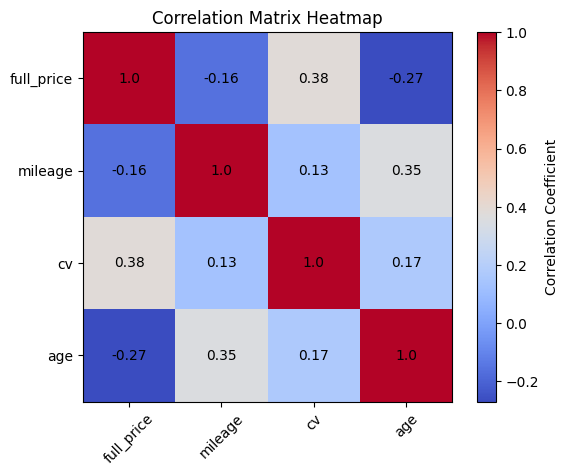

In [176]:
import numpy as np

spearman_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr(method='spearman')
correlation_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, rotation=45)
plt.yticks(range(len(spearman_matrix.columns)), spearman_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Add correlation numbers
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, np.around(correlation_matrix.iloc[i, j], decimals=2),
                       ha="center", va="center", color="black")

# Display the plot
plt.show()
